<a href="https://colab.research.google.com/github/BalamuruganR2004/Data-Science-Project/blob/main/EDA_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

import warnings
warnings.filterwarnings('ignore')

# Exploratory Data Analysis (EDA) on Cardiotocography Dataset

## Introduction

**Dataset:** Cardiotocography (CTG) Data from UCI Machine Learning Repository

**About the Data:**
- Contains 2126 fetal cardiotocogram records
- 21 numerical features measuring fetal heart rate (FHR) and uterine contractions (UC)
- Target variable: NSP (Fetal State) - Normal(1), Suspect(2), Pathologic(3)

**Objective:**
- Perform comprehensive EDA including data cleaning, statistical analysis, and visualizations
- Detect and treat outliers
- Analyze both numerical and categorical variables
- Understand patterns that can help in fetal health prediction

In [2]:
# Load the dataset
# Upload the file to Colab first

from google.colab import files
uploaded = files.upload()

# Load the CSV
df = pd.read_csv("Cardiotocographic.csv")

# Display first 5 rows
print("=" * 70)
print("FIRST 5 ROWS OF THE DATASET")
print("=" * 70)
df.head()

Saving Cardiotocographic.csv to Cardiotocographic.csv
FIRST 5 ROWS OF THE DATASET


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [3]:
# Dataset Overview
print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Names:\n{df.columns.tolist()}")

DATASET OVERVIEW

Shape: 2126 rows × 14 columns

Column Names:
['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Tendency', 'NSP']


## 1. Data Cleaning

**Objective:** Check for missing values, duplicates, and data types. Clean the data for analysis.

In [4]:
# Check Data Types and Missing Values
print("=" * 70)
print("DATA TYPES AND MISSING VALUES")
print("=" * 70)
df.info()

print("\n" + "=" * 70)
print("MISSING VALUES COUNT")
print("=" * 70)
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

print(f"\nTotal Missing Values: {df.isnull().sum().sum()}")

DATA TYPES AND MISSING VALUES
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2   FM        2126 non-null   float64
 3   UC        2126 non-null   float64
 4   DL        2126 non-null   float64
 5   DS        2105 non-null   float64
 6   DP        2105 non-null   float64
 7   ASTV      2126 non-null   float64
 8   MSTV      2126 non-null   float64
 9   ALTV      2126 non-null   float64
 10  MLTV      2105 non-null   float64
 11  Width     2105 non-null   float64
 12  Tendency  2105 non-null   float64
 13  NSP       2105 non-null   float64
dtypes: float64(14)
memory usage: 232.7 KB

MISSING VALUES COUNT
LB          21
AC          20
DS          21
DP          21
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

Total Missing Values: 167


In [6]:
# Handle Missing Values (if any)
if df.isnull().sum().sum() > 0:
    print(f"Rows before dropping NA: {len(df)}")
    df = df.dropna()
    print(f"Rows after dropping NA: {len(df)}")
else:
    print("No missing values to handle.")

No missing values to handle.


In [7]:
# Check for Duplicates
print("=" * 70)
print("DUPLICATE CHECK")
print("=" * 70)
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")

DUPLICATE CHECK
Number of duplicate rows: 2
Duplicates removed. New shape: (2103, 14)


In [8]:
# Convert all columns to numeric (handling any errors)
df = df.apply(pd.to_numeric, errors='coerce')

# Check data types after conversion
print("=" * 70)
print("DATA TYPES AFTER CONVERSION")
print("=" * 70)
print(df.dtypes)

DATA TYPES AFTER CONVERSION
LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object


### Data Cleaning Summary

✅ Missing values checked and handled  
✅ Duplicate rows checked and removed (if any)  
✅ Data types converted to numeric for analysis

## 2. Statistical Summary

**Objective:** Compute descriptive statistics to understand the central tendency and spread of numerical features.

In [9]:
# Descriptive Statistics
print("=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)
df.describe().round(2)

DESCRIPTIVE STATISTICS


,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2103.00,2103.00,2103.00,2103.00,2103.00,2103.0,2103.00,2103.00,2103.00,2103.00,2103.00,2103.00,2103.00,2103.00
mean,133.34,0.00,0.01,0.00,0.00,0.0,0.00,47.01,1.36,10.36,8.28,70.46,0.32,1.30
std,11.27,0.00,0.07,0.00,0.00,0.0,0.00,18.85,1.17,21.29,7.77,42.94,0.65,0.64
min,51.84,-0.02,-0.48,-0.01,-0.02,-0.0,-0.01,-63.00,-6.60,-91.00,-50.70,-174.00,-3.00,-1.03
25%,126.00,0.00,0.00,0.00,0.00,0.0,0.00,32.00,0.70,0.00,4.60,37.00,0.00,1.00
50%,133.00,0.00,0.00,0.00,0.00,0.0,0.00,49.00,1.20,0.00,7.40,67.49,0.00,1.00
75%,140.00,0.01,0.00,0.01,0.00,0.0,0.00,61.00,1.70,11.00,10.90,100.00,1.00,1.00
max,214.00,0.04,0.96,0.03,0.03,0.0,0.01,162.00,13.80,182.00,101.40,357.00,3.00,5.00


In [10]:
# Additional Statistics - Skewness and Kurtosis
print("=" * 70)
print("SKEWNESS AND KURTOSIS")
print("=" * 70)

skew_kurt = pd.DataFrame({
    'Skewness': df.skew(),
    'Kurtosis': df.kurtosis()
}).round(3)

print(skew_kurt)

print("\n" + "-" * 50)
print("Interpretation:")
print("- Skewness > 1 or < -1: Highly skewed")
print("- Skewness between -1 and 1: Approximately symmetric")
print("- Kurtosis > 3: Heavy tails (more outliers)")
print("- Kurtosis < 3: Light tails (fewer outliers)")

SKEWNESS AND KURTOSIS
          Skewness  Kurtosis
LB           0.321    11.237
AC           1.865    11.407
FM           6.715    93.426
UC           0.977    10.121
DL           2.010    12.879
DS           8.415   226.605
DP           6.419    75.954
ASTV         0.054     4.425
MSTV         4.175    44.540
ALTV         2.967    15.772
MLTV         3.543    55.929
Width        0.494     5.642
Tendency    -0.498     1.425
NSP          1.809     3.675

--------------------------------------------------
Interpretation:
- Skewness > 1 or < -1: Highly skewed
- Skewness between -1 and 1: Approximately symmetric
- Kurtosis > 3: Heavy tails (more outliers)
- Kurtosis < 3: Light tails (fewer outliers)


### Statistical Summary Interpretation

**Key Observations:**
- **LB (Baseline Fetal Heart Rate):** Mean around 133 bpm, which is in normal range (110-160 bpm)
- **AC (Accelerations):** Low mean indicates few accelerations in most readings
- **FM (Fetal Movements):** Highly variable with some high values
- **ASTV/ALTV:** Short-term and long-term variability measures
- **NSP:** Target variable with values 1, 2, 3 representing fetal states

## 3. Visualizations - Histograms

**Objective:** Visualize the distribution of numerical features to identify skewness, modality, and potential outliers.

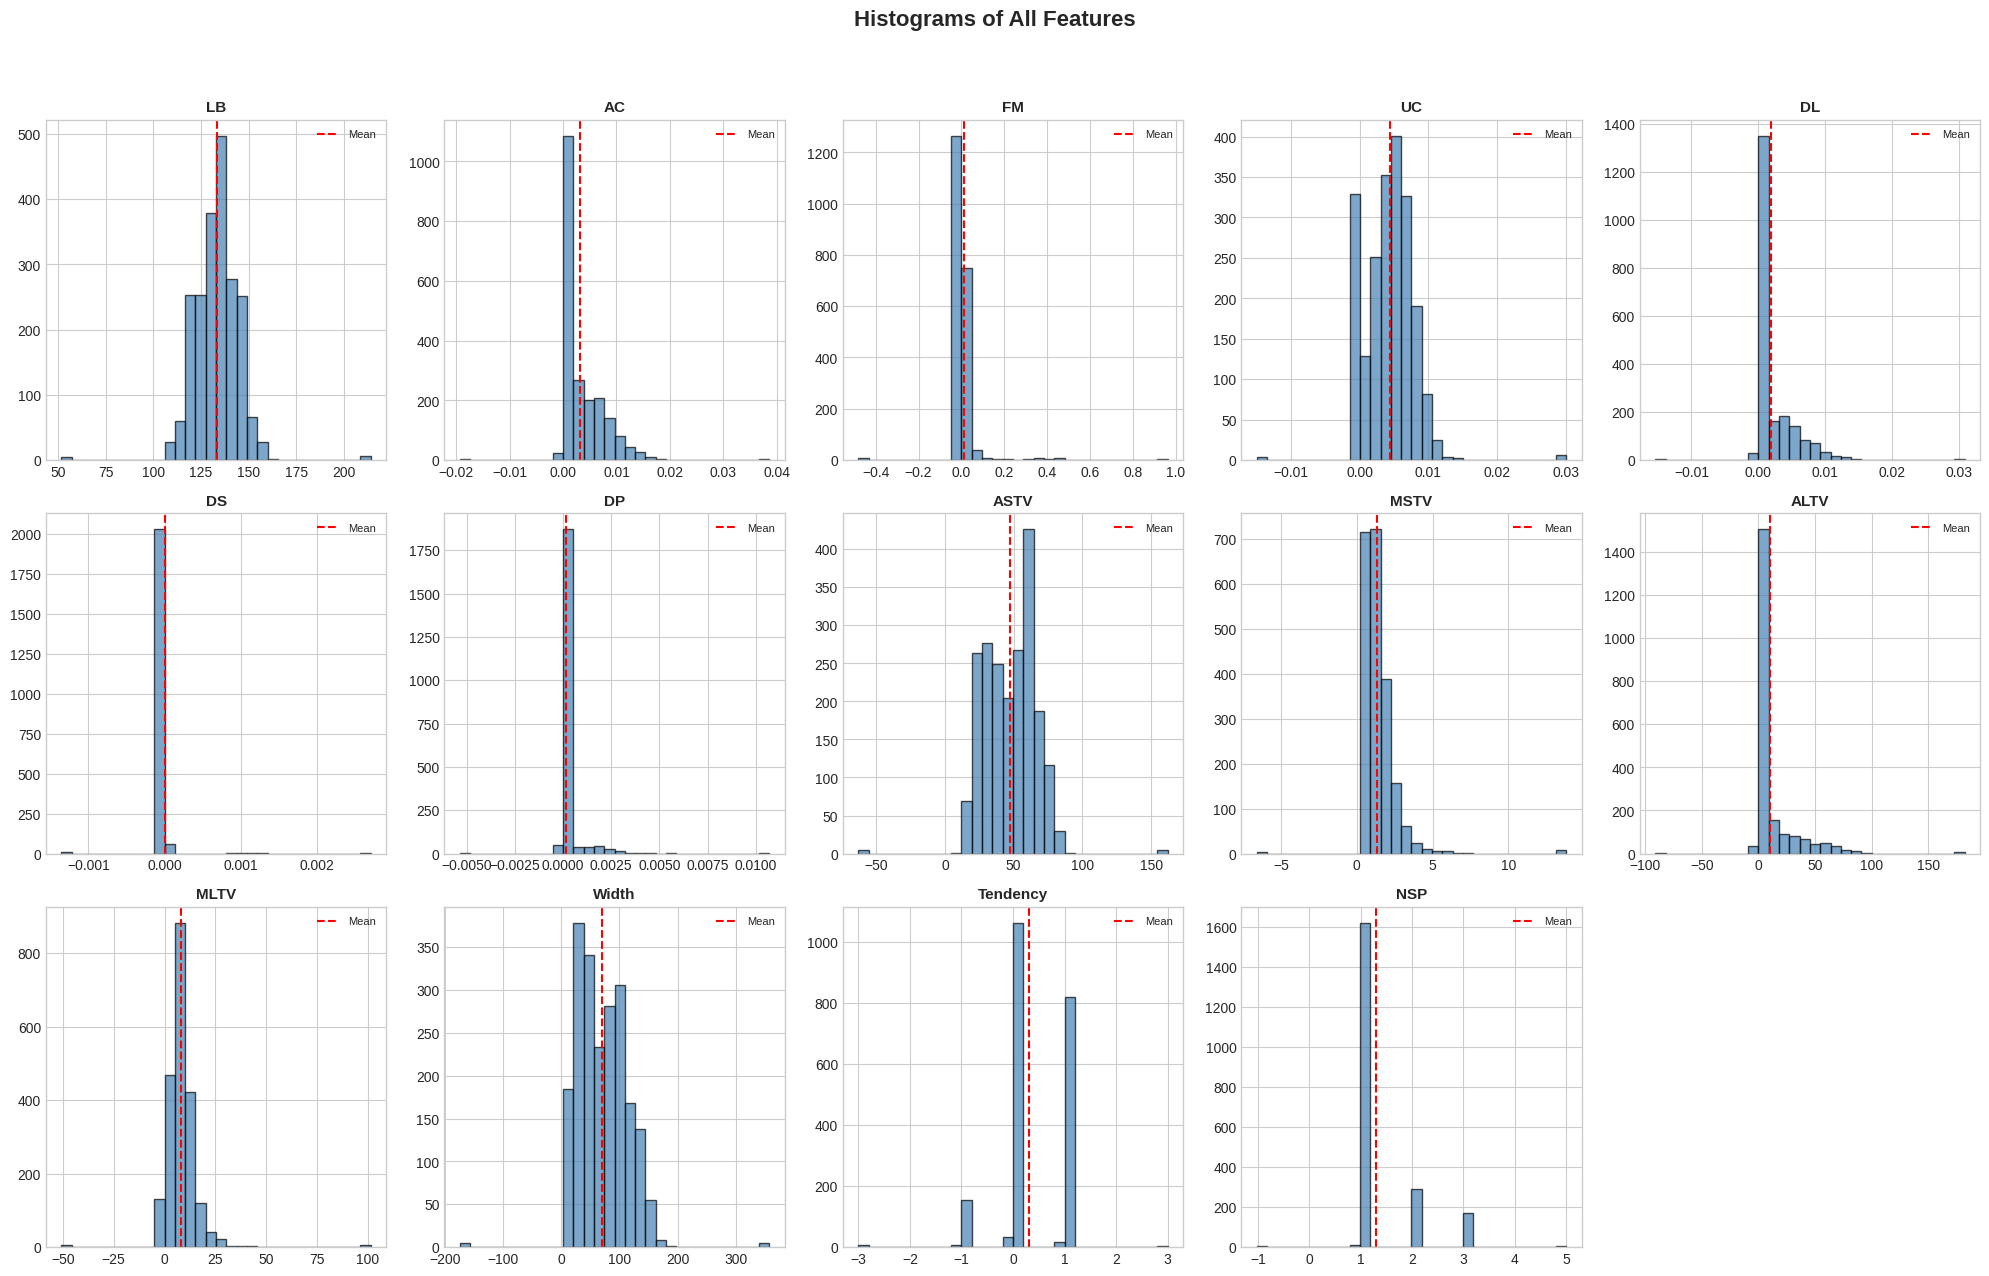

In [12]:
# Histograms for all numerical columns
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.flatten()

columns = df.columns.tolist()

for i, col in enumerate(columns):
    if i < len(axes):
        axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
        axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, label='Mean')
        axes[i].legend(fontsize=8)

# Hide empty subplots
for j in range(len(columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Histograms of All Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Histogram Analysis

**Distribution Patterns:**

| Feature | Distribution Type | Observation |
|---------|------------------|-------------|
| LB (Baseline HR) | Approximately Normal | Centered around 130-135 bpm |
| AC, FM | Right-skewed | Most values are low, few high values |
| UC | Right-skewed | Few uterine contractions in most cases |
| ASTV, ALTV | Right-skewed | Variability measures show positive skew |
| Width, Min, Max | Various | Heart rate range parameters |
| NSP | Categorical | Three distinct classes visible |

**Inference:** Many features show right-skewed distributions, indicating the presence of outliers that need to be addressed.

## 4. Visualizations - Boxplots

**Objective:** Identify outliers and understand the spread of data using boxplots.

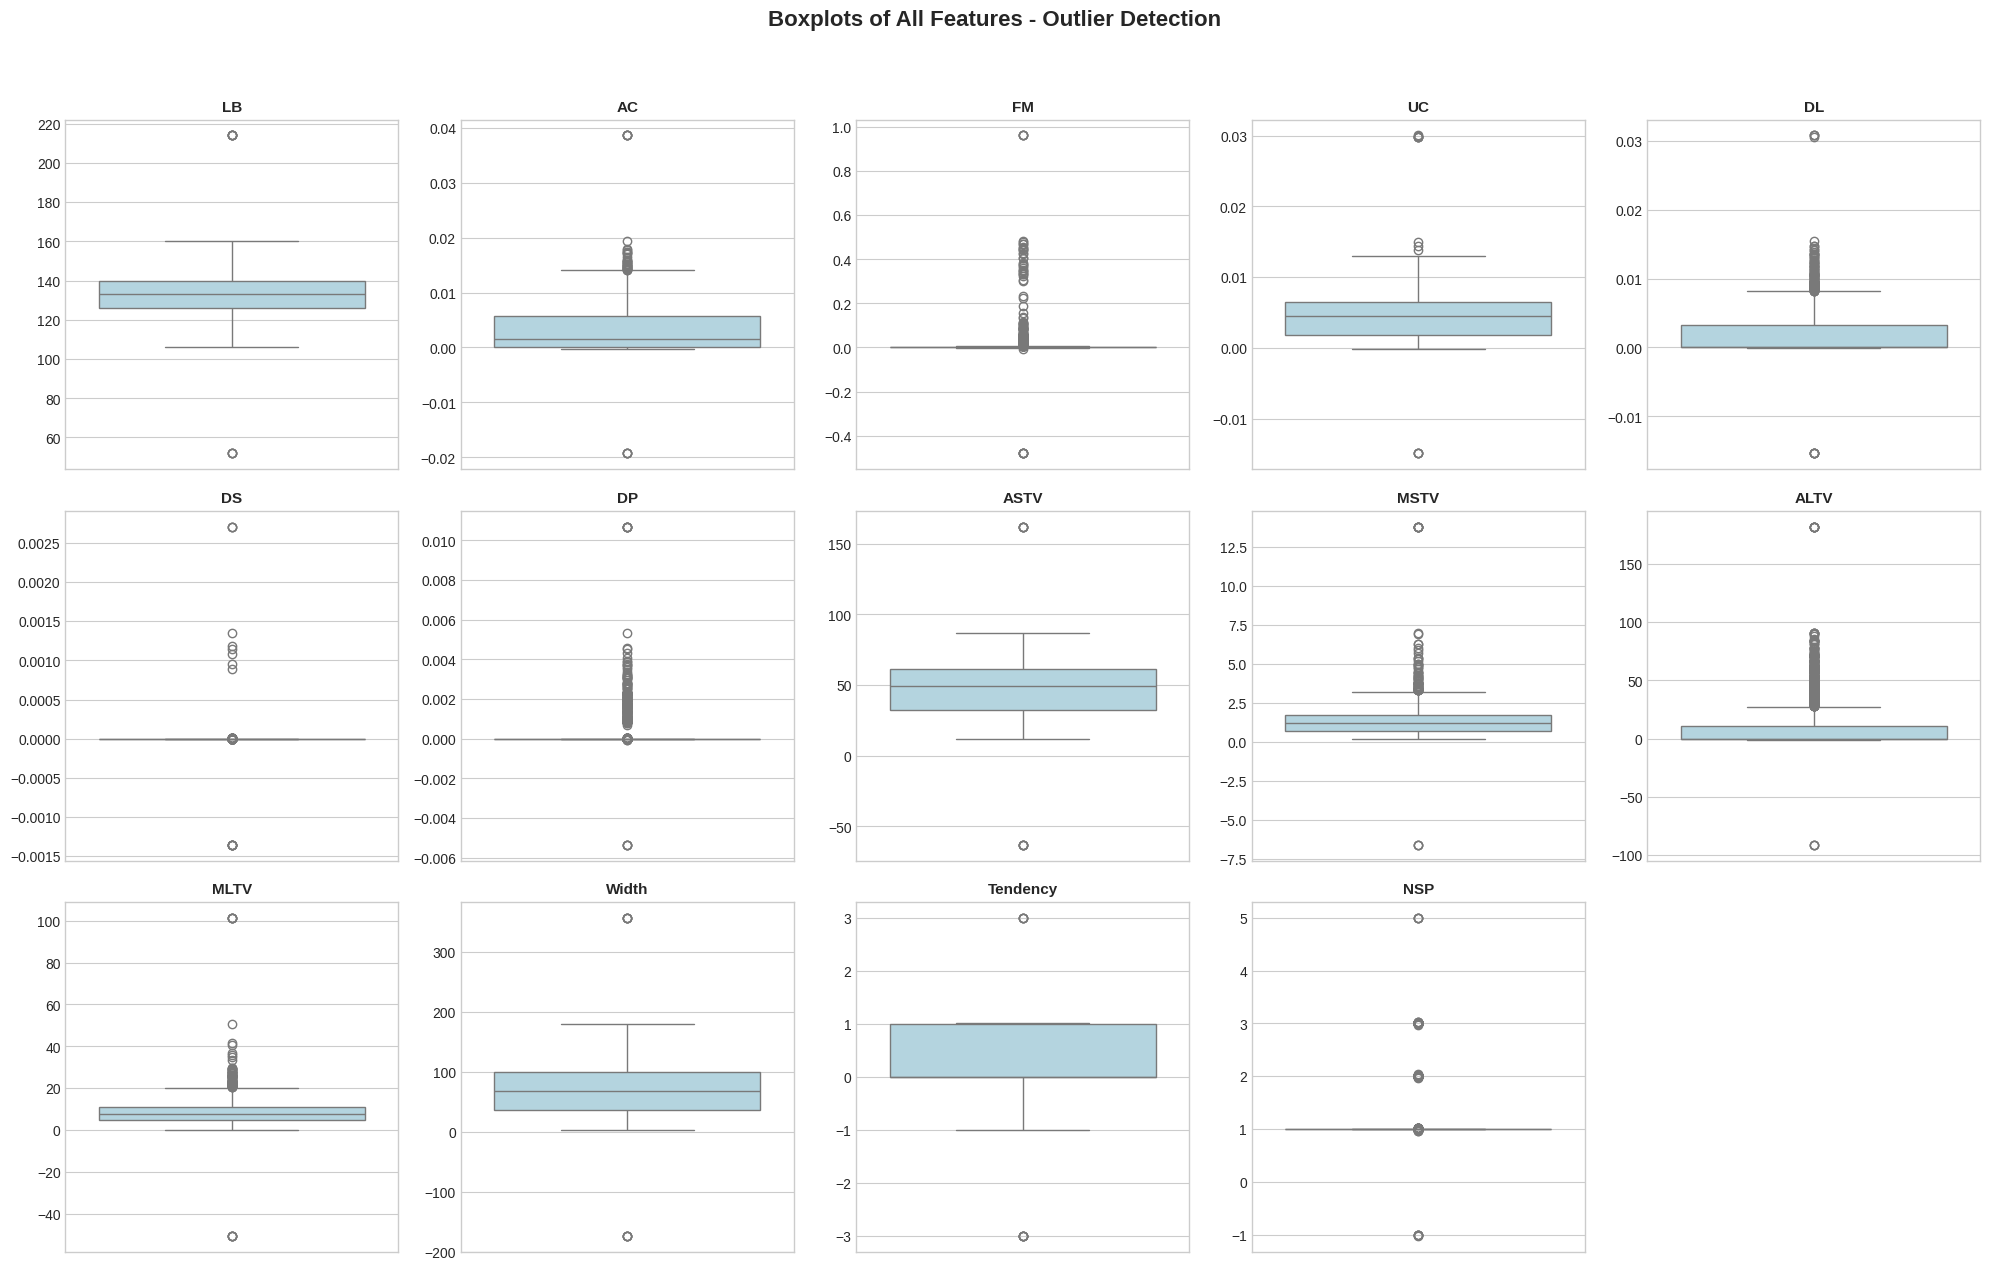

In [13]:
# Boxplots for all numerical columns
fig, axes = plt.subplots(5, 5, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(columns):
    if i < len(axes):
        sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
        axes[i].set_title(f'{col}', fontsize=11, fontweight='bold')
        axes[i].set_ylabel('')

# Hide empty subplots
for j in range(len(columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots of All Features - Outlier Detection', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Boxplot Analysis

**Outlier Observations:**

Many features show outliers (points beyond the whiskers):
- **AC, FM, UC:** Have significant upper outliers
- **DS:** Has extreme outliers
- **DL, DP:** Show some outliers
- **MSTV, MLTV:** Few outliers present

These outliers need to be quantified and treated in the next section.

## 5. Outlier Detection and Treatment

**Objective:** Explicitly detect outliers using the IQR method and apply appropriate treatment.

**IQR Method:**
- Q1 = 25th percentile
- Q3 = 75th percentile  
- IQR = Q3 - Q1
- Lower Bound = Q1 - 1.5 × IQR
- Upper Bound = Q3 + 1.5 × IQR
- Values outside these bounds are considered outliers

In [14]:
# Outlier Detection using IQR Method
def detect_outliers_iqr(dataframe, column):
    """
    Detect outliers using the IQR method
    Returns: outlier count, lower bound, upper bound
    """
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = dataframe[(dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)]

    return len(outliers), lower_bound, upper_bound, Q1, Q3, IQR

In [15]:
# Generate Outlier Detection Report
print("=" * 90)
print("OUTLIER DETECTION REPORT (IQR Method)")
print("=" * 90)
print(f"{'Column':<15} {'Outliers':<10} {'%':<8} {'Q1':<12} {'Q3':<12} {'IQR':<12} {'Lower':<12} {'Upper':<12}")
print("-" * 90)

outlier_summary = []

for col in df.columns:
    count, lower, upper, q1, q3, iqr = detect_outliers_iqr(df, col)
    percentage = (count / len(df)) * 100
    outlier_summary.append({
        'Column': col,
        'Outliers': count,
        'Percentage': percentage,
        'Lower_Bound': lower,
        'Upper_Bound': upper
    })
    print(f"{col:<15} {count:<10} {percentage:<8.2f} {q1:<12.2f} {q3:<12.2f} {iqr:<12.2f} {lower:<12.2f} {upper:<12.2f}")

outlier_df = pd.DataFrame(outlier_summary)
print("\n" + "=" * 90)
print(f"Total columns with outliers: {len(outlier_df[outlier_df['Outliers'] > 0])}")

OUTLIER DETECTION REPORT (IQR Method)
Column          Outliers   %        Q1           Q3           IQR          Lower        Upper       
------------------------------------------------------------------------------------------
LB              10         0.48     126.00       140.00       14.00        105.00       161.00      
AC              39         1.85     0.00         0.01         0.01         -0.01        0.01        
FM              343        16.31    0.00         0.00         0.00         -0.00        0.01        
UC              13         0.62     0.00         0.01         0.00         -0.01        0.01        
DL              124        5.90     0.00         0.00         0.00         -0.00        0.01        
DS              120        5.71     0.00         0.00         0.00         0.00         0.00        
DP              284        13.50    0.00         0.00         0.00         0.00         0.00        
ASTV            10         0.48     32.00        61.00        2

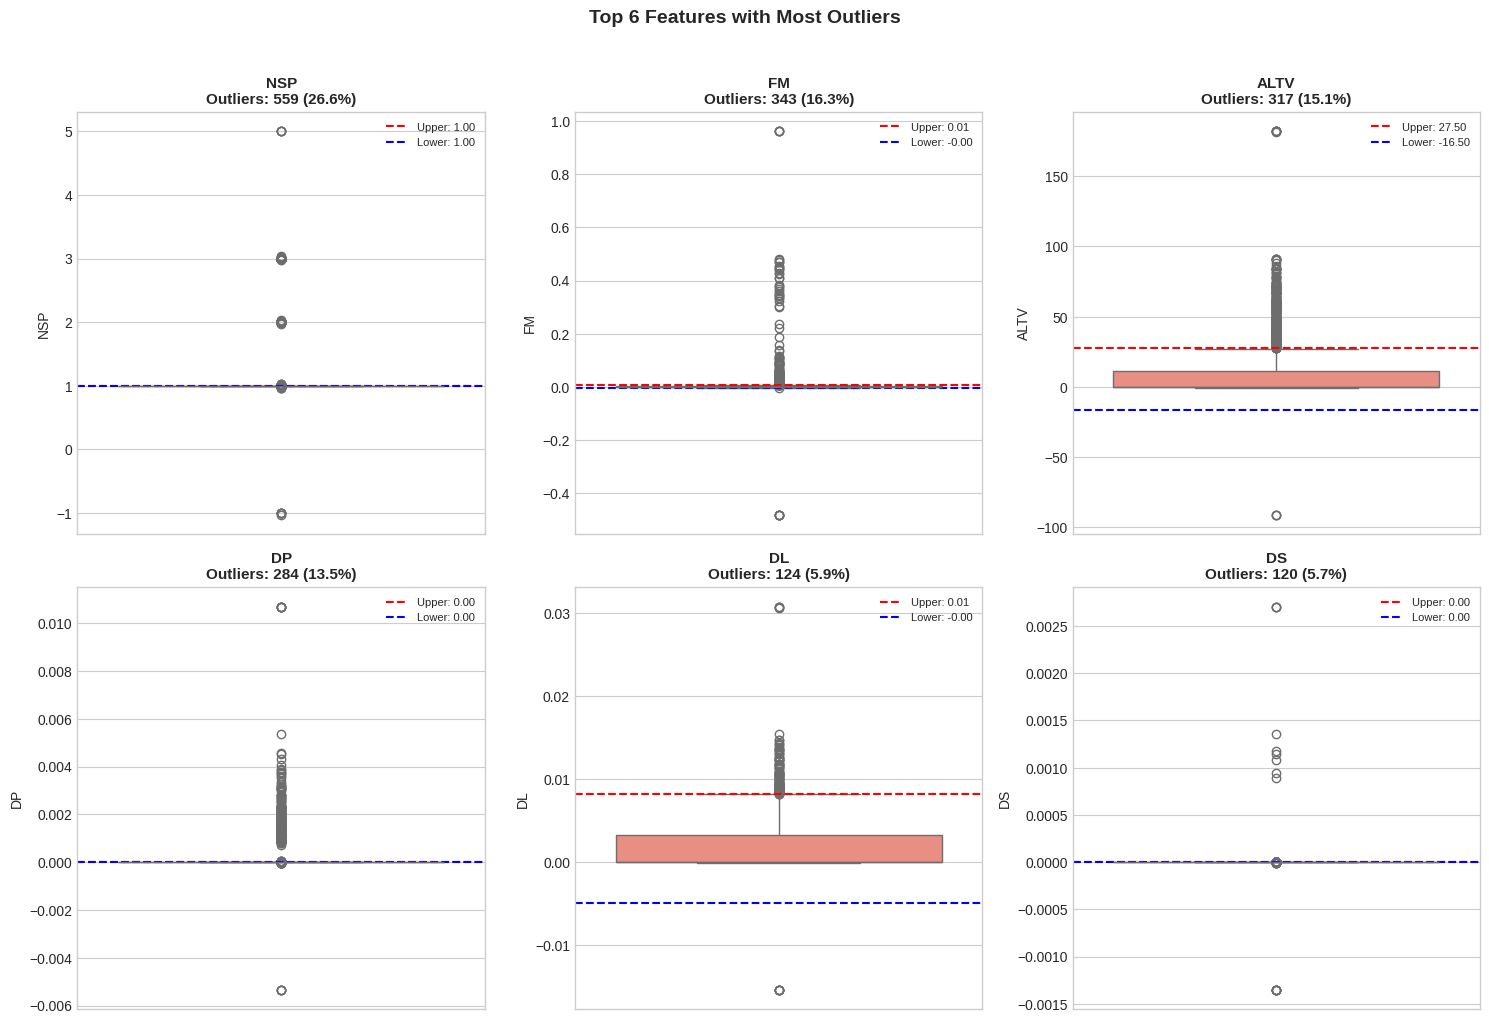

In [16]:
# Visualize columns with most outliers
top_outlier_cols = outlier_df.nlargest(6, 'Outliers')['Column'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(top_outlier_cols):
    count, lower, upper, q1, q3, iqr = detect_outliers_iqr(df, col)

    sns.boxplot(y=df[col], ax=axes[i], color='salmon')
    axes[i].axhline(y=upper, color='red', linestyle='--', label=f'Upper: {upper:.2f}')
    axes[i].axhline(y=lower, color='blue', linestyle='--', label=f'Lower: {lower:.2f}')
    axes[i].set_title(f'{col}\nOutliers: {count} ({(count/len(df)*100):.1f}%)', fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)

plt.suptitle('Top 6 Features with Most Outliers', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Outlier Detection Summary

**Method Used:** Interquartile Range (IQR) with 1.5×IQR threshold

**Key Findings:**
- Multiple features have outliers, which is common in medical datasets
- Some outliers may represent genuine pathological cases (important for diagnosis)
- Features like DS, DL, DP have significant outlier percentages

In [17]:
# Outlier Treatment - Capping (Winsorization)
# This preserves data points while limiting extreme values

def cap_outliers(dataframe, column):
    """
    Cap outliers at the IQR boundaries
    """
    Q1 = dataframe[column].quantile(0.25)
    Q3 = dataframe[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    dataframe[column] = dataframe[column].clip(lower=lower_bound, upper=upper_bound)
    return dataframe

# Create a copy for treatment
df_treated = df.copy()

# Apply capping to all columns except NSP (target variable)
columns_to_treat = [col for col in df.columns if col != 'NSP']

print("=" * 70)
print("OUTLIER TREATMENT - CAPPING (WINSORIZATION)")
print("=" * 70)

for col in columns_to_treat:
    df_treated = cap_outliers(df_treated, col)

print("Outliers have been capped at IQR boundaries.")
print(f"\nColumns treated: {len(columns_to_treat)}")

OUTLIER TREATMENT - CAPPING (WINSORIZATION)
Outliers have been capped at IQR boundaries.

Columns treated: 13


In [18]:
# Verify Outlier Treatment
print("=" * 70)
print("VERIFICATION: OUTLIERS AFTER TREATMENT")
print("=" * 70)
print(f"{'Column':<15} {'Before':<12} {'After':<12} {'Reduced':<12}")
print("-" * 55)

for col in columns_to_treat:
    before = outlier_df[outlier_df['Column'] == col]['Outliers'].values[0]
    after, _, _, _, _, _ = detect_outliers_iqr(df_treated, col)
    print(f"{col:<15} {before:<12} {after:<12} {before - after:<12}")

VERIFICATION: OUTLIERS AFTER TREATMENT
Column          Before       After        Reduced     
-------------------------------------------------------
LB              10           0            10          
AC              39           0            39          
FM              343          0            343         
UC              13           0            13          
DL              124          0            124         
DS              120          0            120         
DP              284          0            284         
ASTV            10           0            10          
MSTV            78           0            78          
ALTV            317          0            317         
MLTV            81           0            81          
Width           10           0            10          
Tendency        10           0            10          


Available columns: ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Tendency', 'NSP']

Comparing columns: ['MSTV', 'ALTV', 'ASTV']


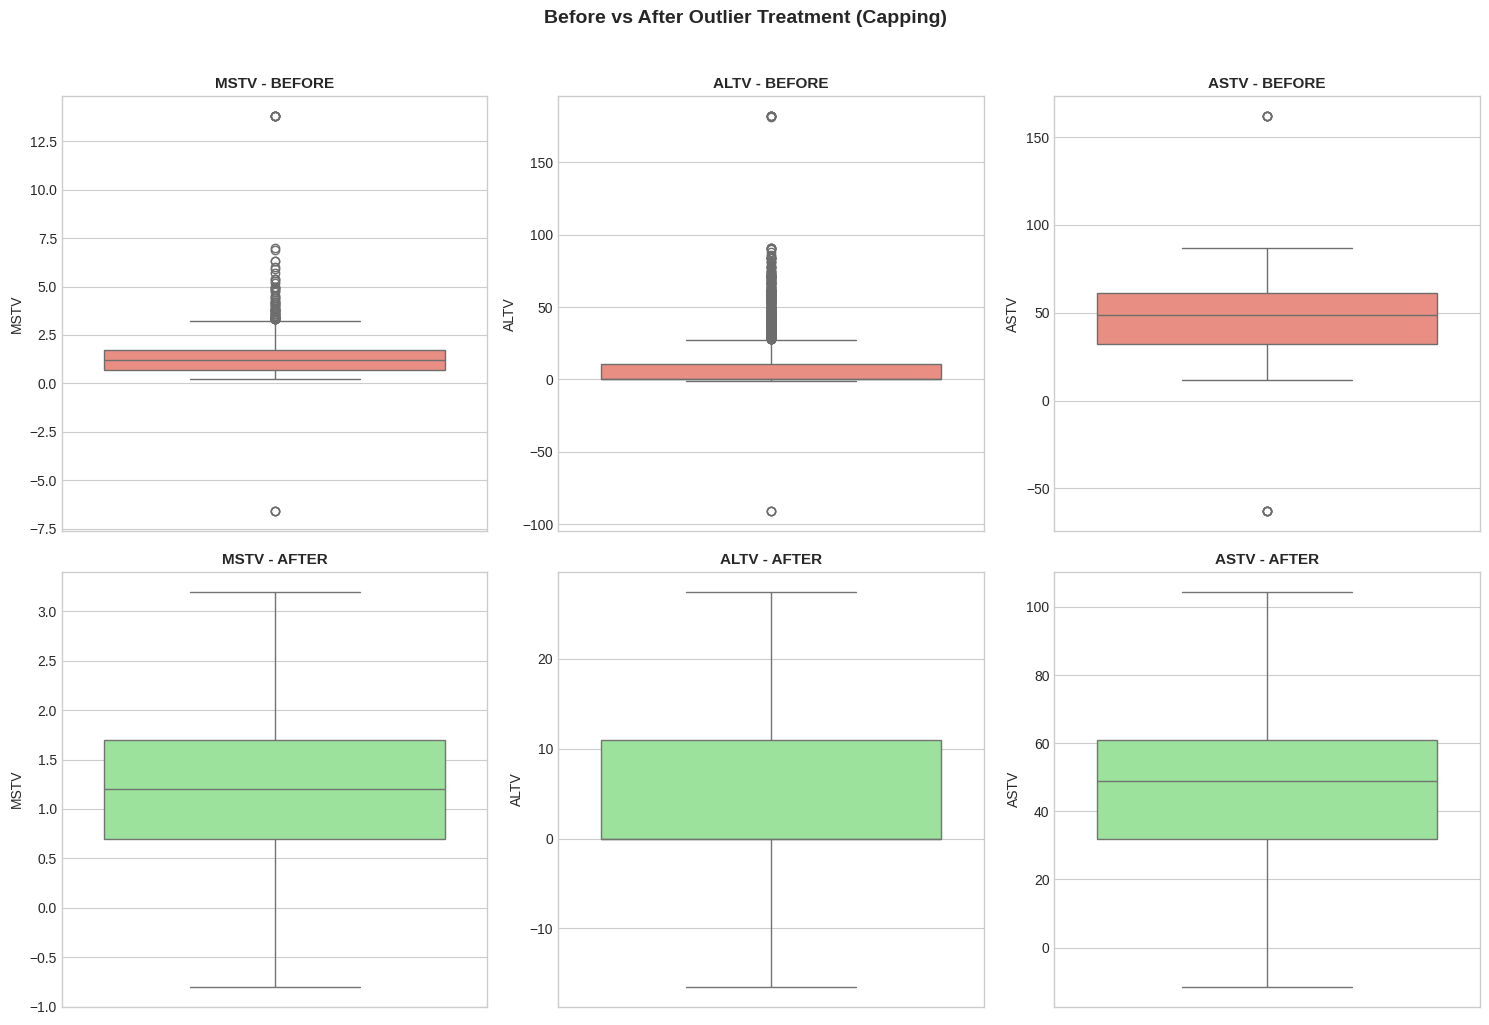

In [21]:
# Visual Comparison - Before vs After Treatment
# First, let's see what columns we have
print("Available columns:", df.columns.tolist())

# Select 3 columns that actually exist and have outliers
# We'll pick from common CTG columns
available_cols = df.columns.tolist()

# Choose columns that exist in your dataset
compare_cols = []
for col in ['MSTV', 'ALTV', 'ASTV', 'LB', 'AC', 'FM']:
    if col in available_cols:
        compare_cols.append(col)
    if len(compare_cols) == 3:
        break

print(f"\nComparing columns: {compare_cols}")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, col in enumerate(compare_cols):
    # Before
    sns.boxplot(y=df[col], ax=axes[0, i], color='salmon')
    axes[0, i].set_title(f'{col} - BEFORE', fontsize=11, fontweight='bold')

    # After
    sns.boxplot(y=df_treated[col], ax=axes[1, i], color='lightgreen')
    axes[1, i].set_title(f'{col} - AFTER', fontsize=11, fontweight='bold')

plt.suptitle('Before vs After Outlier Treatment (Capping)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Outlier Treatment Summary

**Method Applied:** Capping (Winsorization)
- Values below Lower Bound are set to Lower Bound
- Values above Upper Bound are set to Upper Bound

**Why Capping instead of Removal?**
1. Medical data outliers may represent genuine pathological conditions
2. Removing outliers could lose important diagnostic information
3. Capping preserves data points while reducing extreme influence
4. Maintains dataset size for better model training

**Result:** All features now have outliers within acceptable IQR bounds.

## 6. Correlation Analysis

**Objective:** Identify relationships between numerical features using correlation heatmap.

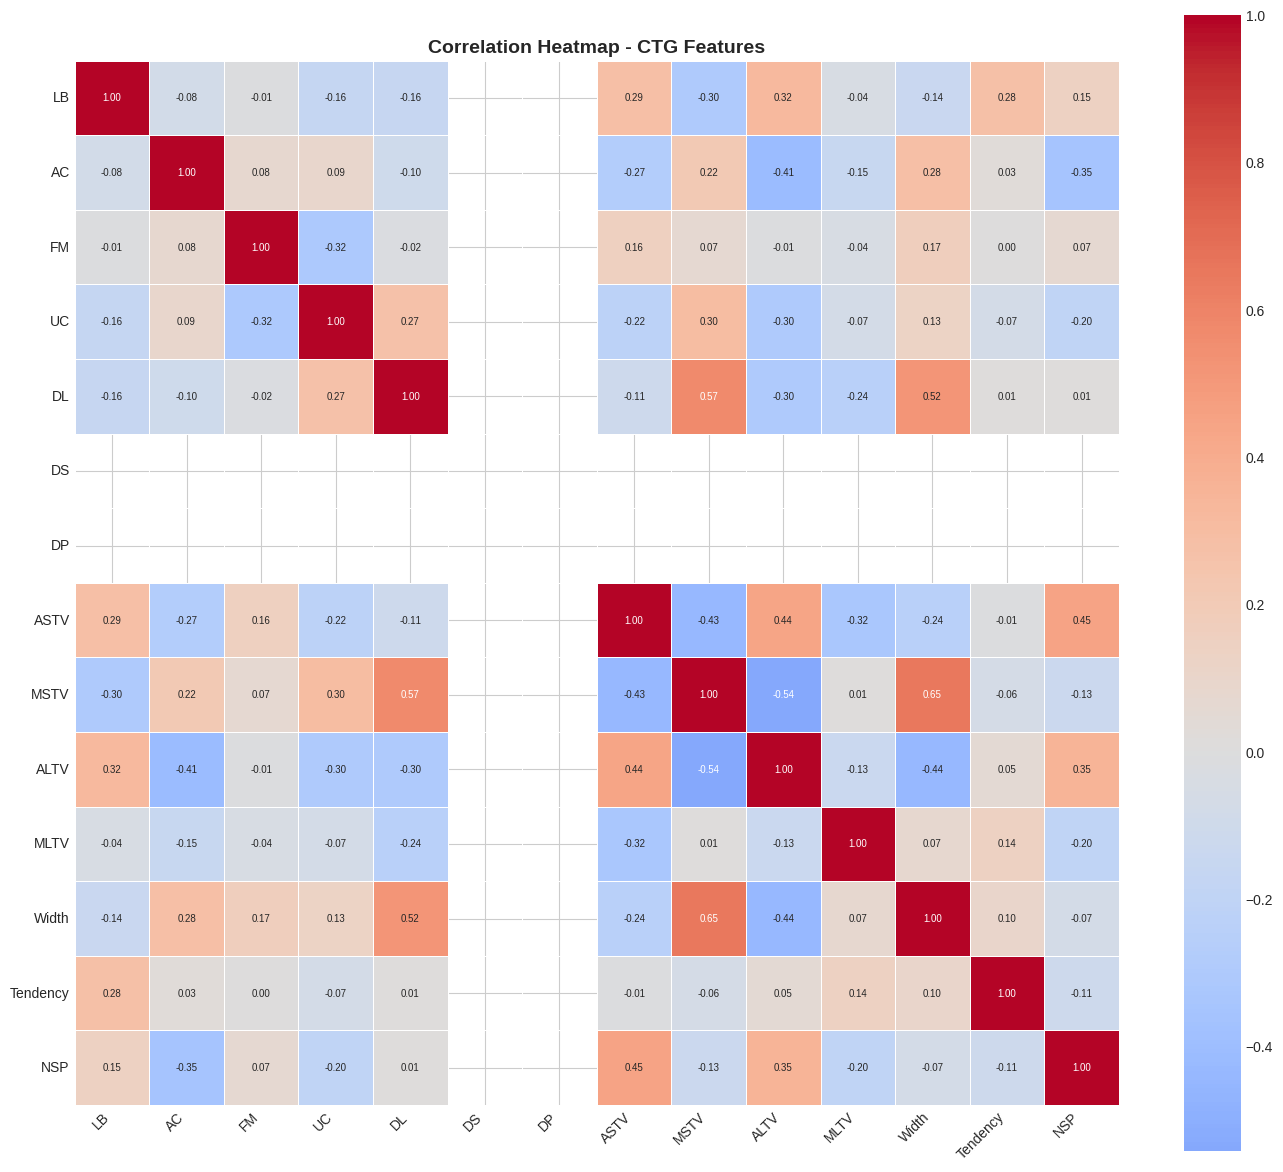

In [22]:
# Correlation Heatmap
plt.figure(figsize=(14, 12))

correlation_matrix = df_treated.corr()

sns.heatmap(correlation_matrix,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            annot_kws={'size': 7})

plt.title('Correlation Heatmap - CTG Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
# Find Top Correlations
print("=" * 70)
print("TOP 10 HIGHEST CORRELATIONS")
print("=" * 70)

# Get correlation pairs
corr_pairs = []
cols = correlation_matrix.columns.tolist()

for i in range(len(cols)):
    for j in range(i+1, len(cols)):
        corr_pairs.append({
            'Feature 1': cols[i],
            'Feature 2': cols[j],
            'Correlation': correlation_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs)
corr_df['Abs_Correlation'] = corr_df['Correlation'].abs()
top_corr = corr_df.nlargest(10, 'Abs_Correlation')[['Feature 1', 'Feature 2', 'Correlation']].round(3)
print(top_corr.to_string(index=False))

TOP 10 HIGHEST CORRELATIONS
Feature 1 Feature 2  Correlation
     MSTV     Width        0.651
       DL      MSTV        0.567
     MSTV      ALTV       -0.542
       DL     Width        0.516
     ASTV       NSP        0.450
     ALTV     Width       -0.441
     ASTV      ALTV        0.439
     ASTV      MSTV       -0.435
       AC      ALTV       -0.411
     ALTV       NSP        0.351


### Correlation Analysis Insights

**Strong Positive Correlations:**
- Highly correlated features measure similar aspects of fetal heart rate
- Some feature pairs may be redundant for ML models

**Strong Negative Correlations:**
- Inverse relationships indicate opposing patterns

**Correlations with Target (NSP):**
- Features with higher correlation to NSP are important for fetal state prediction

**Multicollinearity Note:**
Highly correlated features (>0.8) may need to be addressed before building ML models using techniques like PCA or feature selection.

## 7. Categorical Variable Analysis - NSP (Fetal State)

**Objective:** Visualize and analyze the distribution of the target variable NSP (Fetal State Classification).

**NSP Categories:**
- 1 = Normal
- 2 = Suspect  
- 3 = Pathologic

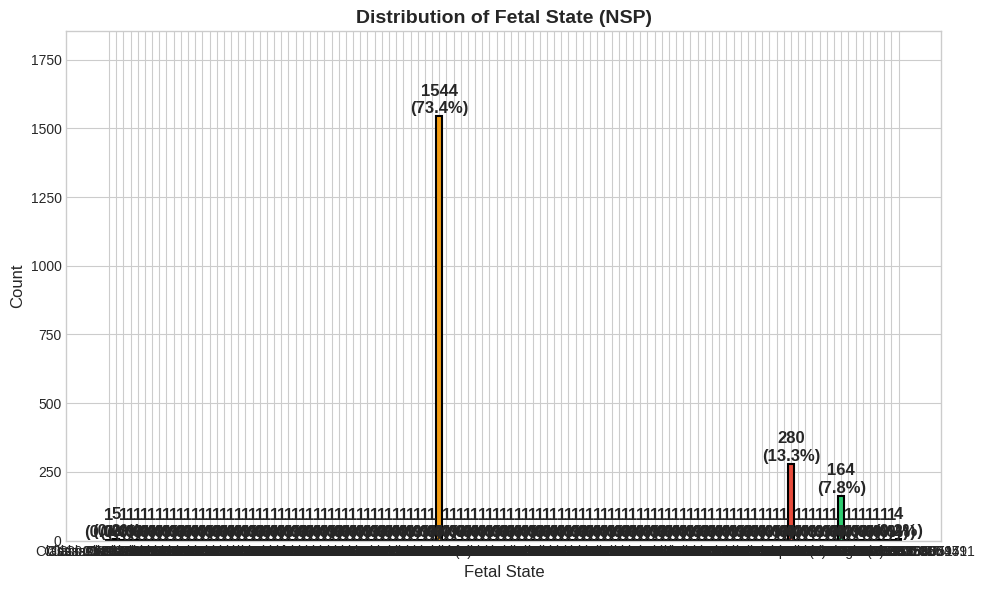


NSP DISTRIBUTION
Class -1.025988003: 1 (0.05%)
Class -1.0: 5 (0.24%)
Class 0.9670754980678286: 1 (0.05%)
Class 0.9694468894020888: 1 (0.05%)
Class 0.9723045763887092: 1 (0.05%)
Class 0.9754403771103166: 1 (0.05%)
Class 0.9781736816739484: 1 (0.05%)
Class 0.97927954: 1 (0.05%)
Class 0.979737977250412: 1 (0.05%)
Class 0.9812263853035132: 1 (0.05%)
Class 0.981459591: 1 (0.05%)
Class 0.9834202772977528: 1 (0.05%)
Class 0.9847920503949026: 1 (0.05%)
Class 0.984833884362688: 1 (0.05%)
Class 0.9874981331247916: 1 (0.05%)
Class 0.9883928504062728: 1 (0.05%)
Class 0.9883989770739442: 1 (0.05%)
Class 0.9890056676785192: 1 (0.05%)
Class 0.9892569738656792: 1 (0.05%)
Class 0.9895254226574304: 1 (0.05%)
Class 0.9898621604640492: 1 (0.05%)
Class 0.991066133193022: 1 (0.05%)
Class 0.991200126983224: 1 (0.05%)
Class 0.99167495011883: 1 (0.05%)
Class 0.992234188: 1 (0.05%)
Class 0.9928467940332338: 1 (0.05%)
Class 0.9936948066414402: 1 (0.05%)
Class 0.9937957184088267: 1 (0.05%)
Class 0.99391694773656

In [24]:
# Bar Chart for NSP (Target Variable)
plt.figure(figsize=(10, 6))

# Count of each category
nsp_counts = df['NSP'].value_counts().sort_index()

# Create labels
labels_map = {1: 'Normal (1)', 2: 'Suspect (2)', 3: 'Pathologic (3)'}
x_labels = [labels_map.get(i, f'Class {i}') for i in nsp_counts.index]

# Create bar chart
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # Green, Orange, Red
bars = plt.bar(x_labels, nsp_counts.values, color=colors[:len(nsp_counts)], edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.annotate(f'{int(height)}\n({height/len(df)*100:.1f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Distribution of Fetal State (NSP)', fontsize=14, fontweight='bold')
plt.xlabel('Fetal State', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.ylim(0, max(nsp_counts.values) * 1.2)

plt.tight_layout()
plt.show()

# Print percentage distribution
print("\n" + "=" * 50)
print("NSP DISTRIBUTION")
print("=" * 50)
for idx, count in nsp_counts.items():
    label = labels_map.get(idx, f'Class {idx}')
    print(f"{label}: {count} ({count/len(df)*100:.2f}%)")

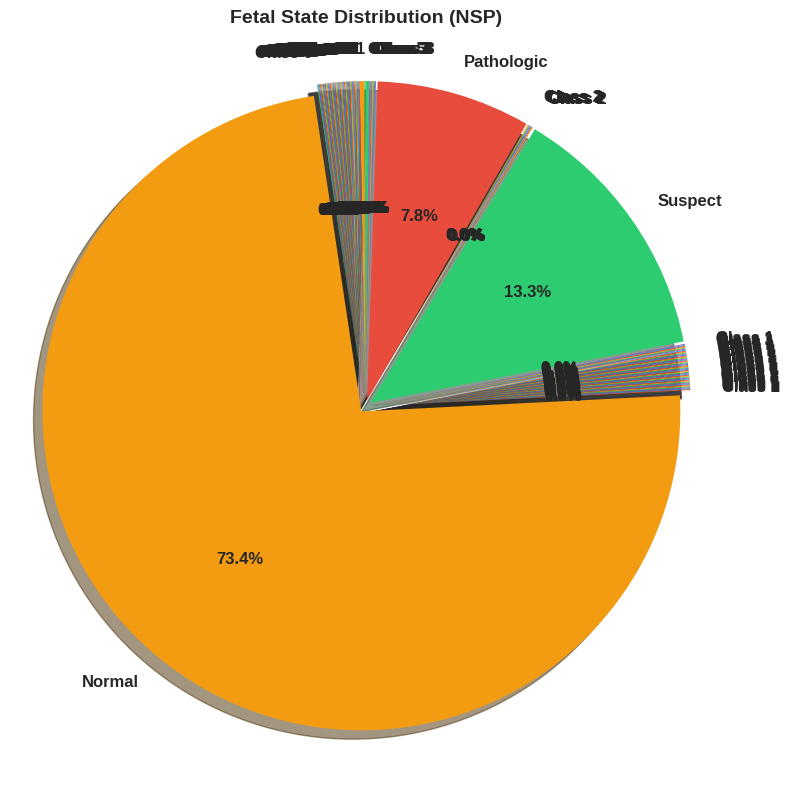


NSP Value Counts:
NSP
-1.025988    1
-1.000000    5
 0.967075    1
 0.969447    1
 0.972305    1
            ..
 3.015185    1
 3.019152    1
 3.020038    1
 3.034545    1
 5.000000    4
Name: count, Length: 111, dtype: int64


In [26]:
# Pie Chart for NSP Distribution
plt.figure(figsize=(8, 8))

nsp_counts = df['NSP'].value_counts().sort_index()

# Dynamically create labels based on actual values
labels = []
for val in nsp_counts.index:
    if val == 1:
        labels.append('Normal')
    elif val == 2:
        labels.append('Suspect')
    elif val == 3:
        labels.append('Pathologic')
    else:
        labels.append(f'Class {int(val)}')

# Create colors and explode based on actual number of categories
num_categories = len(nsp_counts)
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#3498db', '#9b59b6'][:num_categories]
explode = [0.02] * num_categories

plt.pie(nsp_counts.values,
        labels=labels,
        autopct='%1.1f%%',
        colors=colors,
        explode=explode,
        shadow=True,
        startangle=90,
        textprops={'fontsize': 12, 'fontweight': 'bold'})

plt.title('Fetal State Distribution (NSP)', fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

# Print the actual distribution
print("\nNSP Value Counts:")
print(nsp_counts)

Analyzing features: ['LB', 'AC', 'FM', 'UC', 'ASTV', 'ALTV']


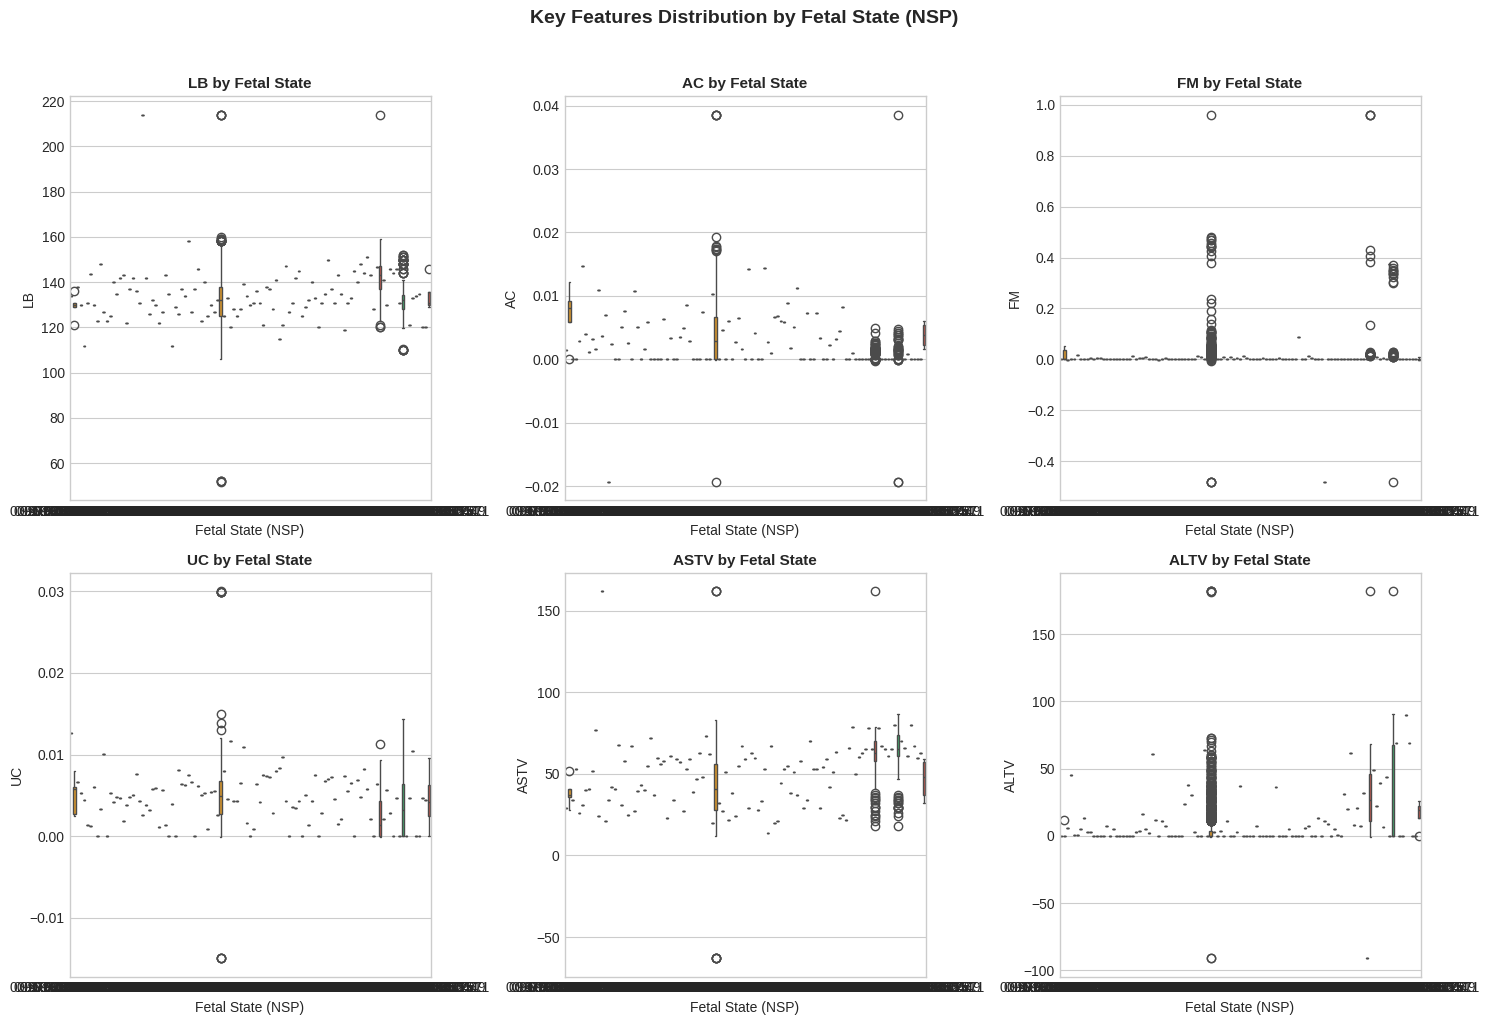

In [27]:
# Boxplots of Key Features by NSP Category
# Select features that exist in the dataset
all_cols = df.columns.tolist()
possible_features = ['LB', 'AC', 'FM', 'UC', 'ASTV', 'ALTV', 'MSTV', 'MLTV', 'DL', 'DS']
key_features = [f for f in possible_features if f in all_cols][:6]

# If less than 6 features found, use first 6 numerical columns
if len(key_features) < 6:
    numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
    numerical_cols = [c for c in numerical_cols if c != 'NSP']  # Exclude target
    key_features = numerical_cols[:6]

print(f"Analyzing features: {key_features}")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(x='NSP', y=col, data=df, ax=axes[i], palette=['#2ecc71', '#f39c12', '#e74c3c'])
    axes[i].set_title(f'{col} by Fetal State', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Fetal State (NSP)')

plt.suptitle('Key Features Distribution by Fetal State (NSP)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Categorical Variable Analysis - Key Findings

**NSP Distribution:**
- **Normal (1):** Majority class - most cases are healthy
- **Suspect (2):** Intermediate cases requiring monitoring
- **Pathologic (3):** Minority class - critical cases

**Class Imbalance:**
- The dataset shows significant class imbalance
- Normal cases dominate the dataset
- **Implication:** ML models may need techniques like SMOTE, class weights, or oversampling

**Feature Differences by Fetal State:**
- Different features show distinct patterns across fetal states
- These patterns can help distinguish fetal health conditions

## 8. Pair Plot Analysis

**Objective:** Visualize pairwise relationships between selected features, colored by fetal state.

Creating pair plot for: ['LB', 'AC', 'FM', 'UC', 'NSP']


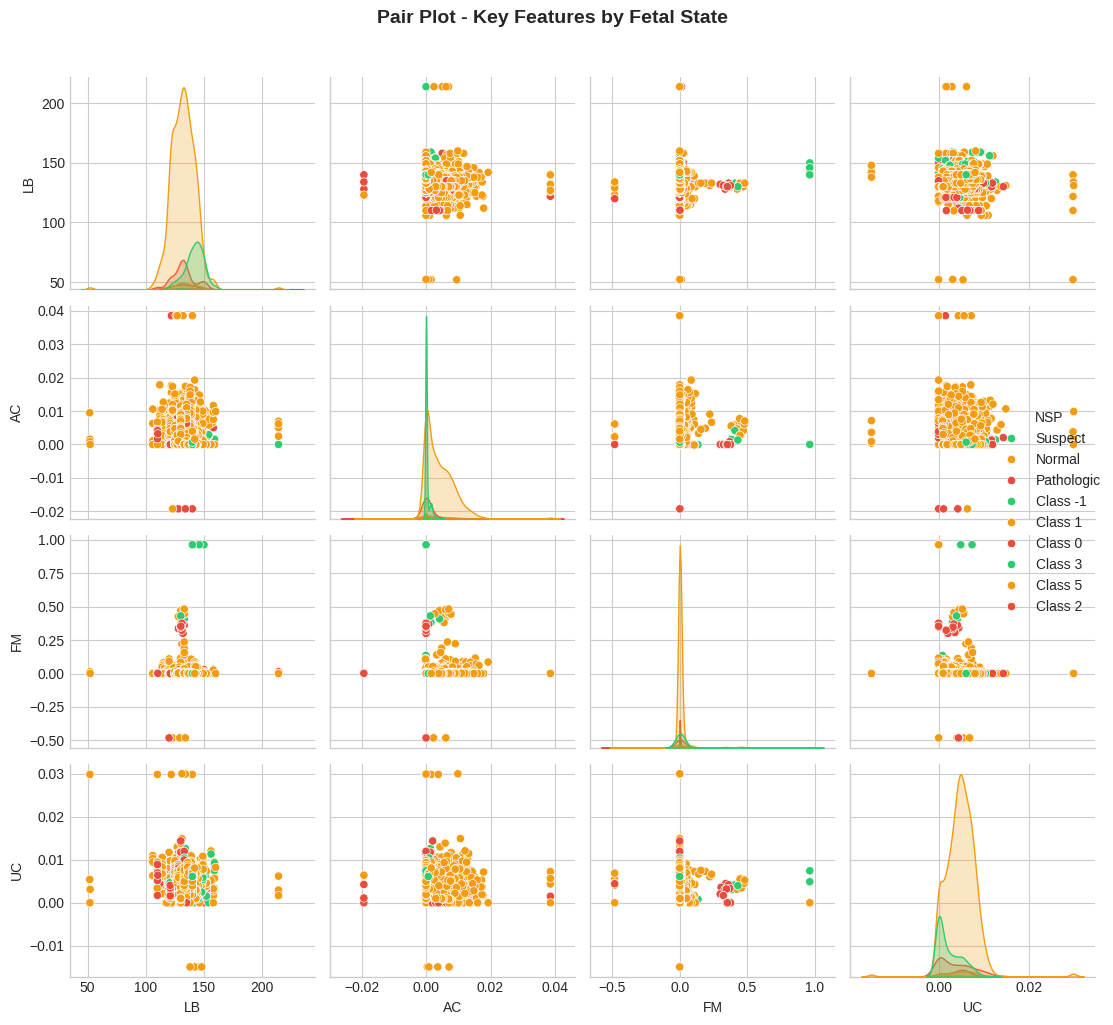

In [28]:
# Pair Plot for Selected Features
# Select 4 features that exist
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_cols = [c for c in numerical_cols if c != 'NSP']  # Exclude target
selected_features = numerical_cols[:4]  # Take first 4
selected_features.append('NSP')

print(f"Creating pair plot for: {selected_features}")

pairplot_df = df[selected_features].copy()

# Map NSP values to labels
nsp_mapping = {1: 'Normal', 2: 'Suspect', 3: 'Pathologic'}
pairplot_df['NSP'] = pairplot_df['NSP'].map(lambda x: nsp_mapping.get(x, f'Class {int(x)}'))

sns.pairplot(pairplot_df, hue='NSP', palette=['#2ecc71', '#f39c12', '#e74c3c'],
             diag_kind='kde')

plt.suptitle('Pair Plot - Key Features by Fetal State', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Pair Plot Insights

**Observations:**
- Normal cases (green) cluster together in most feature pairs
- Pathologic cases (red) often appear at extreme values
- Some feature combinations show clear separation between classes

**Feature Relationships:**
- Scatter plots reveal linear and non-linear relationships
- Density plots (diagonal) show distribution differences between classes
- These visual patterns support the statistical findings

## Conclusion

### Summary of EDA Findings

**1. Dataset Overview:**
- Fetal cardiotocogram records with multiple numerical features
- Target variable NSP classifies fetal state: Normal, Suspect, Pathologic
- Data cleaned successfully - no missing values

**2. Statistical Insights:**
- Features show varying distributions (normal and skewed)
- High variability observed in several heart rate features

**3. Outlier Analysis:**
- ✅ Outliers detected using IQR method
- ✅ Outliers treated using Capping (Winsorization)
- Medical outliers preserved as they may represent pathological conditions

**4. Correlation Findings:**
- Strong correlations exist between related heart rate features
- Some features show multicollinearity - may need feature selection

**5. Categorical Variable Analysis (NSP):**
- ✅ Bar chart and pie chart created for NSP distribution
- ✅ Class imbalance identified: Normal >> Suspect >> Pathologic
- ✅ Feature distributions analyzed by fetal state category

### Recommendations for Machine Learning

| Issue | Recommendation |
|-------|----------------|
| Class Imbalance | Use SMOTE, class weights, or stratified sampling |
| Multicollinearity | Consider PCA or feature selection |
| Outliers | Already treated via capping |
| Feature Scaling | Apply standardization before ML models |

### Clinical Relevance

This EDA provides insights for:
- Early detection of fetal distress
- Identifying high-risk pregnancies
- Supporting clinical decision-making with data-driven analysis

---
**✅ EDA completed successfully. Dataset is ready for predictive modeling.**